In [ ]:
!pip install tensorflow tensorflow-datasets faiss-cpu numpy matplotlib seaborn

In [10]:
import os
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_datasets as tfds

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

In [11]:
ds_base = tfds.load("sift1m", split="database", as_supervised=False)
ds_test = tfds.load("sift1m", split="test", as_supervised=False)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating database examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/sift1m/incomplete.F6RJ88_1.0.0/sift1m-database.tfrecord*...:   0%|        …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/sift1m/incomplete.F6RJ88_1.0.0/sift1m-test.tfrecord*...:   0%|          | …

Dataset sift1m downloaded and prepared to /root/tensorflow_datasets/sift1m/1.0.0. Subsequent calls will reuse this data.


In [19]:
for example in ds_base.take(1):
    print(example.keys())

dict_keys(['embedding', 'index', 'neighbors'])


In [20]:

base_vectors = np.array([x['embedding'] for x in tfds.as_numpy(ds_base)], dtype='float32')
query_vectors = np.array([x['embedding'] for x in tfds.as_numpy(ds_test)], dtype='float32')

print(f"Database: {base_vectors.shape}")
print(f"Query: {query_vectors.shape}")

Database: (1000000, 128)
Query: (10000, 128)


3) Для каждого вектора-запроса в исходном датасете при помощи kNN составить списки точных 100 соседей - их считаем ground truth

Предустановленный Ground Truth

In [21]:
gt_precomputed = []
for x in tfds.as_numpy(ds_test):
    gt_precomputed.append(x['neighbors']['index'])

gt_precomputed = np.array(gt_precomputed, dtype='int32')

if gt_precomputed.shape[1] > 100:
    gt_precomputed = gt_precomputed[:, :100]

print(f"Ground Truth: {gt_precomputed.shape}")

Ground Truth: (10000, 100)


Ground Truth вручную

In [23]:
index_flat = faiss.IndexFlatL2(128)
index_flat.add(base_vectors)

start_time = time.time()
distance, gt_manual = index_flat.search(query_vectors, 100)

sample_idx = 0
matches = np.intersect1d(gt_manual[sample_idx], gt_precomputed[sample_idx]).size
print(f"Совпадение для запроса №0: {matches}/100")


Совпадение для запроса №0: 100/100


In [24]:
# gt_final = gt_manual
gt_final = gt_precomputed

4) Выбрать любую библиотеку в которой уже есть готовые реализации LSH/HNSW/IVF+PQ

In [26]:
import faiss


Функция оценки Recall

In [31]:
def evaluate_index(index, queries, ground_truth, k=100):
    start_time = time.time()
    distances, indices = index.search(queries, k)
    end_time = time.time()

    total_queries = ground_truth.shape[0] # 10 000
    correct_hits = 0

    for i in range(total_queries):
        intersect_count = np.intersect1d(indices[i], ground_truth[i]).size
        correct_hits += intersect_count

    recall = correct_hits / (total_queries * k)

    total_time = end_time - start_time
    qps = total_queries / total_time

    return recall, qps

# LSH
* nbits - количество бит в хэше

In [33]:
lsh_results = []
dimension = 128

for nbits in [64, 128, 256, 512, 1024]:
    print(f"LSH с nbits={nbits}")

    index_lsh = faiss.IndexLSH(dimension, nbits)

    start_build = time.time()
    index_lsh.add(base_vectors)
    build_duration = time.time() - start_build

    recall, qps = evaluate_index(index_lsh, query_vectors, gt_final)

    lsh_results.append({
        'nbits': nbits,
        'recall': recall,
        'qps': qps,
        'build_time': build_duration
    })

    print(f"  Результат: Recall = {recall:.4f}, QPS = {qps:.1f}, Построение = {build_duration:.2f}с")


LSH с nbits=64
  Результат: Recall = 0.0865, QPS = 419.2, Построение = 0.54с
LSH с nbits=128
  Результат: Recall = 0.1838, QPS = 342.1, Построение = 1.08с
LSH с nbits=256
  Результат: Recall = 0.3056, QPS = 358.6, Построение = 1.84с
LSH с nbits=512
  Результат: Recall = 0.4561, QPS = 207.5, Построение = 4.75с
LSH с nbits=1024
  Результат: Recall = 0.5857, QPS = 49.1, Построение = 9.56с


# HNSW

* m - количество связей для каждого узла
* ef_value - размер списка кандидатов на 100 ближайших соседей


In [35]:
hnsw_results = []
dimension = 128

for m_value in [16, 32]:
    print(f"HNSW с M={m_value}")

    index_hnsw = faiss.IndexHNSWFlat(dimension, m_value)

    start_build = time.time()
    index_hnsw.add(base_vectors)
    build_duration = time.time() - start_build

    for ef_value in [100, 200, 500]:
        index_hnsw.hnsw.efSearch = ef_value

        recall, qps = evaluate_index(index_hnsw, query_vectors, gt_final)

        hnsw_results.append({
            'M': m_value,
            'efSearch': ef_value,
            'recall': recall,
            'qps': qps,
            'build_time': build_duration
        })

        print(f"Результат: efSearch={ef_value:3} | Recall: {recall:.4f} | QPS: {qps:.1f}, Построение = {build_duration:.2f}с")


HNSW с M=16
Результат: efSearch=100 | Recall: 0.8644 | QPS: 2962.5, Построение = 168.13с
Результат: efSearch=200 | Recall: 0.9407 | QPS: 2162.1, Построение = 168.13с
Результат: efSearch=500 | Recall: 0.9844 | QPS: 558.6, Построение = 168.13с
HNSW с M=32
Результат: efSearch=100 | Recall: 0.9549 | QPS: 2086.5, Построение = 277.56с
Результат: efSearch=200 | Recall: 0.9867 | QPS: 1010.6, Построение = 277.56с
Результат: efSearch=500 | Recall: 0.9981 | QPS: 502.5, Построение = 277.56с


# IVF+PQ
* nlist_options: на сколько кластеров делим базу
* m_options: на сколько частей режем вектор для сжатия
* nprobe_options: сколько ближайших кластеров проверять при поиске *Курсив*

In [37]:
ivfpq_results = []
dimension = 128

m_options = [16, 32]
nlist_options = [1024, 2048, 4096]
nprobe_options = [1, 5, 10, 50, 100]

for m in m_options:
    for nlist in nlist_options:
        print(f"Clusters={nlist}, m={m}")

        quantizer = faiss.IndexFlatL2(dimension)
        index_ivf = faiss.IndexIVFPQ(quantizer, dimension, nlist, m, 8)

        start_train = time.time()
        index_ivf.train(base_vectors)
        train_time = time.time() - start_train

        start_add = time.time()
        index_ivf.add(base_vectors)
        add_time = time.time() - start_add

        build_time_total = train_time + add_time


        print(f"Построено за {build_time_total:.2f}с (Train: {train_time:.1f}с)")

        for nprobe in nprobe_options:
            index_ivf.nprobe = nprobe

            recall, qps = evaluate_index(index_ivf, query_vectors, gt_final)

            ivfpq_results.append({
                'algorithm': 'IVF+PQ',
                'nlist': nlist,
                'm': m,
                'nprobe': nprobe,
                'recall': recall,
                'qps': qps,
                'build_time': build_time_total
            })

            print(f"Реезультаты: nprobe={nprobe:3} | Recall: {recall:.4f} | QPS: {qps:.1f}")


Clusters=1024, m=16
Построено за 34.66с (Train: 22.1с)
Реезультаты: nprobe=  1 | Recall: 0.2751 | QPS: 17663.2
Реезультаты: nprobe=  5 | Recall: 0.5310 | QPS: 6748.4
Реезультаты: nprobe= 10 | Recall: 0.5951 | QPS: 3216.4
Реезультаты: nprobe= 50 | Recall: 0.6441 | QPS: 802.0
Реезультаты: nprobe=100 | Recall: 0.6462 | QPS: 290.8
Clusters=2048, m=16
Построено за 94.07с (Train: 76.1с)
Реезультаты: nprobe=  1 | Recall: 0.2351 | QPS: 24583.4
Реезультаты: nprobe=  5 | Recall: 0.4920 | QPS: 5578.6
Реезультаты: nprobe= 10 | Recall: 0.5718 | QPS: 3789.2
Реезультаты: nprobe= 50 | Recall: 0.6462 | QPS: 1520.9
Реезультаты: nprobe=100 | Recall: 0.6517 | QPS: 723.0
Clusters=4096, m=16
Построено за 272.37с (Train: 242.5с)
Реезультаты: nprobe=  1 | Recall: 0.1910 | QPS: 15397.3
Реезультаты: nprobe=  5 | Recall: 0.4458 | QPS: 7156.8
Реезультаты: nprobe= 10 | Recall: 0.5405 | QPS: 6966.7
Реезультаты: nprobe= 50 | Recall: 0.6457 | QPS: 2431.9
Реезультаты: nprobe=100 | Recall: 0.6571 | QPS: 1103.0
Clusters

In [38]:
import pandas as pd

df_lsh = pd.DataFrame(lsh_results)
df_hnsw = pd.DataFrame(hnsw_results)
df_ivf = pd.DataFrame(ivfpq_results)

df_lsh['label'] = 'LSH'
df_hnsw['label'] = 'HNSW (M=' + df_hnsw['M'].astype(str) + ')'
df_ivf['label'] = 'IVF' + df_ivf['nlist'].astype(str) + '+PQ(m=' + df_ivf['m'].astype(str) + ')'


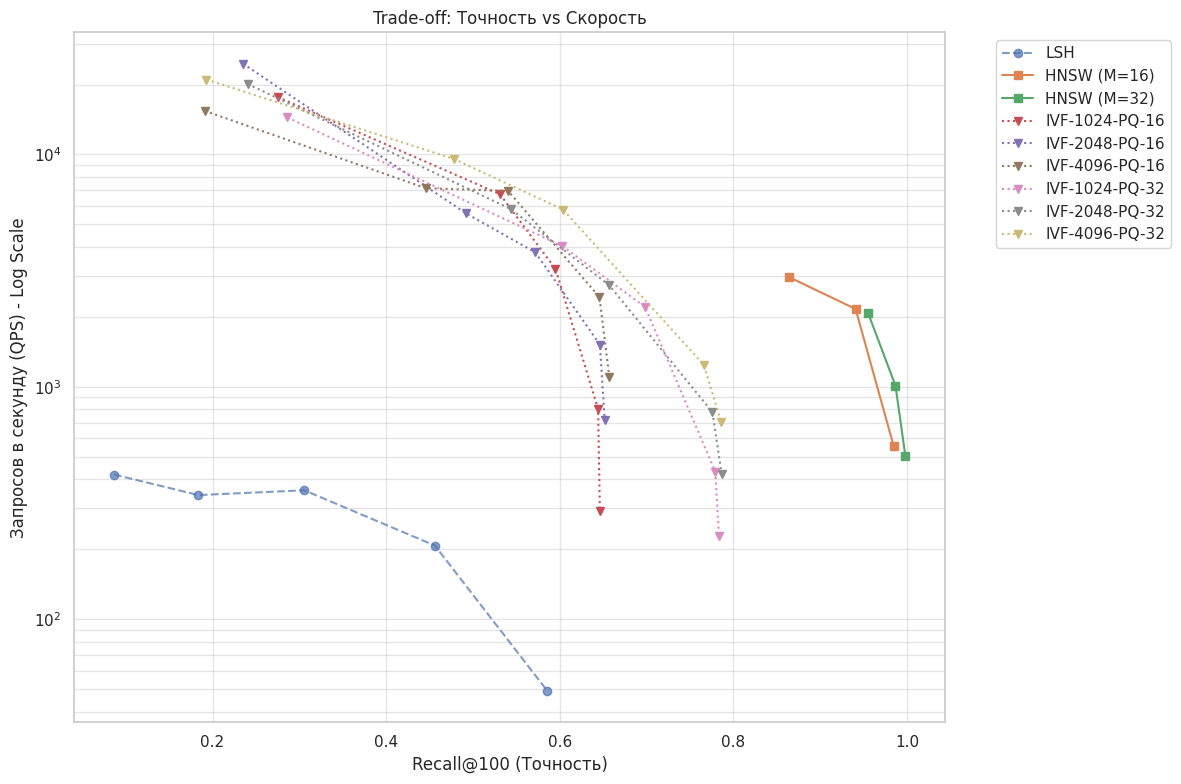

In [39]:
plt.figure(figsize=(12, 8))

plt.plot(df_lsh['recall'], df_lsh['qps'], 'o--', label='LSH', alpha=0.7)

for m in df_hnsw['M'].unique():
    subset = df_hnsw[df_hnsw['M'] == m]
    plt.plot(subset['recall'], subset['qps'], 's-', label=f'HNSW (M={m})')

for m_pq in df_ivf['m'].unique():
    for nlist in df_ivf['nlist'].unique():
        subset = df_ivf[(df_ivf['m'] == m_pq) & (df_ivf['nlist'] == nlist)]
        plt.plot(subset['recall'], subset['qps'], 'v:', label=f'IVF-{nlist}-PQ-{m_pq}')

plt.yscale('log')
plt.xlabel('Recall@100 (Точность)')
plt.ylabel('Запросов в секунду (QPS) - Log Scale')
plt.title('Trade-off: Точность vs Скорость')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

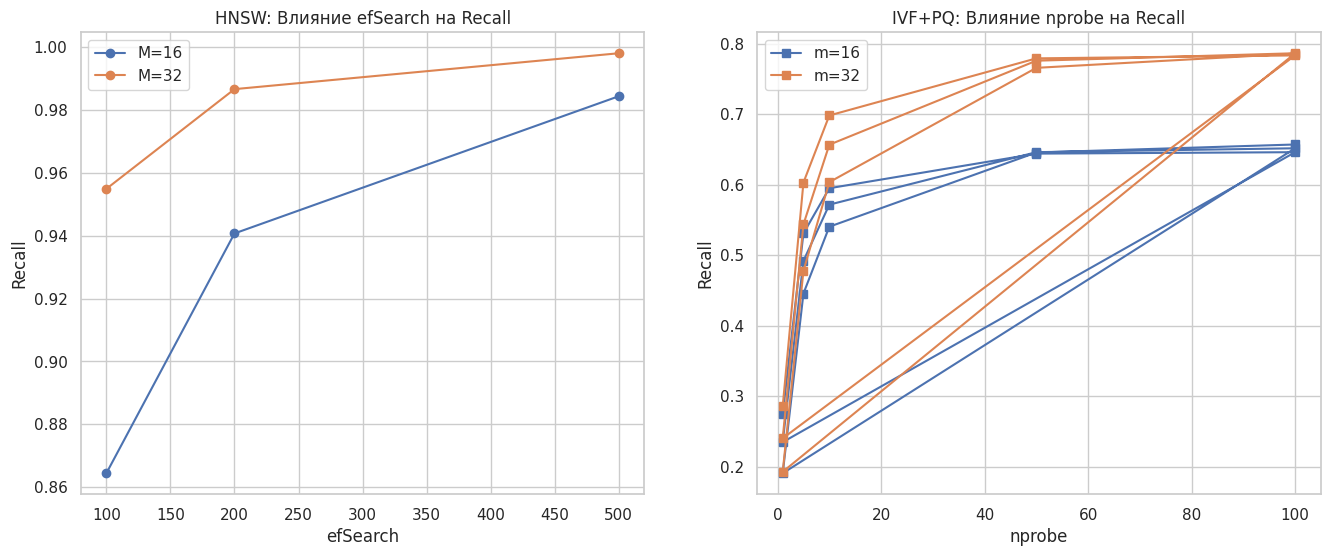

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for m in df_hnsw['M'].unique():
    subset = df_hnsw[df_hnsw['M'] == m]
    ax1.plot(subset['efSearch'], subset['recall'], 'o-', label=f'M={m}')
ax1.set_title('HNSW: Влияние efSearch на Recall')
ax1.set_xlabel('efSearch')
ax1.set_ylabel('Recall')
ax1.legend()

for m in df_ivf['m'].unique():
    subset = df_ivf[(df_ivf['m'] == m)]
    ax2.plot(subset['nprobe'], subset['recall'], 's-', label=f'm={m}, nlist=1024')
ax2.set_title('IVF+PQ: Влияние nprobe на Recall')
ax2.set_xlabel('nprobe')
ax2.set_ylabel('Recall')
ax2.legend()

plt.show()

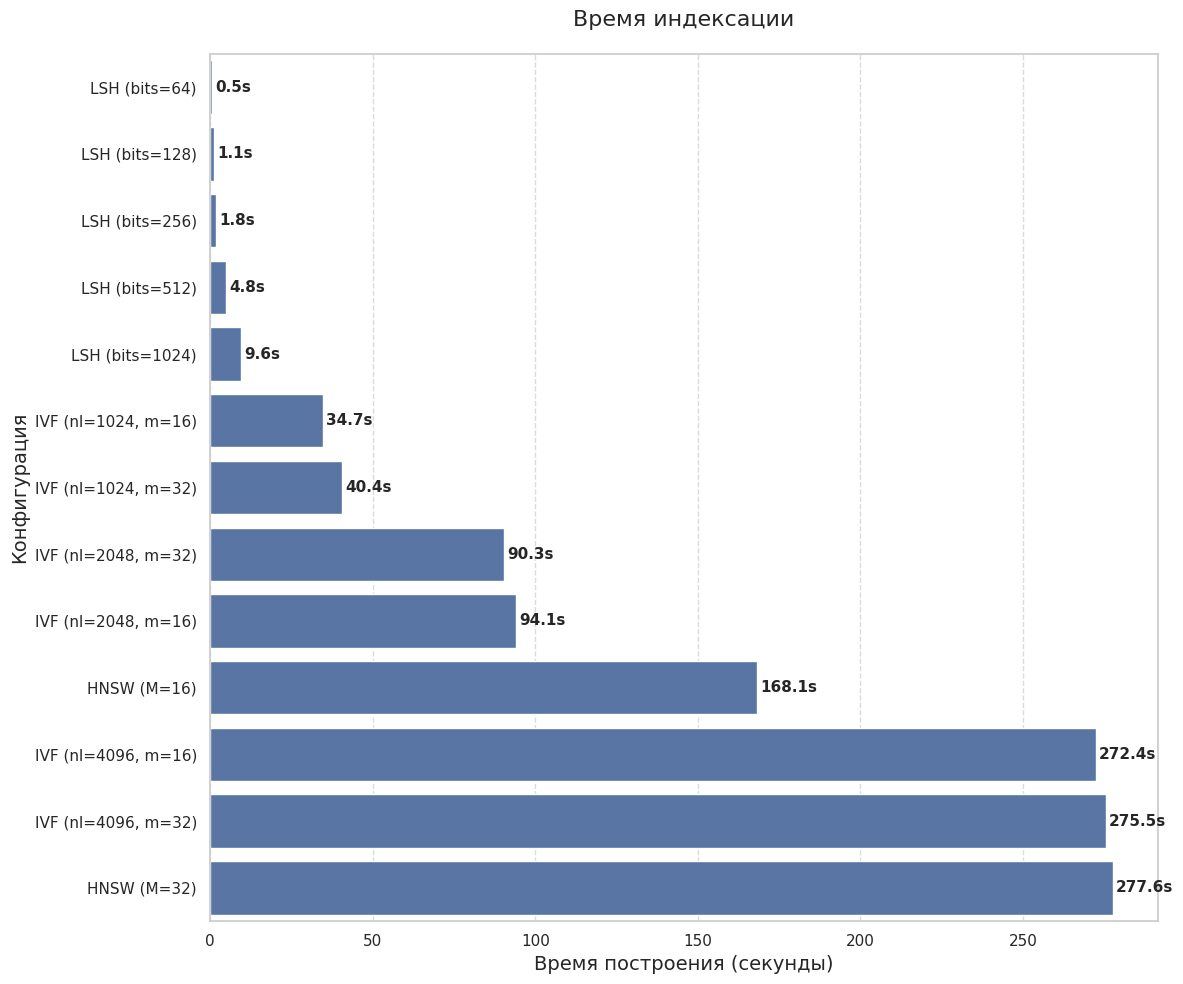

In [52]:
lsh_bt = df_lsh[['nbits', 'build_time']].drop_duplicates().copy()
lsh_bt['Config'] = 'LSH (bits=' + lsh_bt['nbits'].astype(str) + ')'

hnsw_bt = df_hnsw[['M', 'build_time']].drop_duplicates().copy()
hnsw_bt['Config'] = 'HNSW (M=' + hnsw_bt['M'].astype(str) + ')'

ivf_bt = df_ivf[['nlist', 'm', 'build_time']].drop_duplicates().copy()
ivf_bt['Config'] = 'IVF (nl=' + ivf_bt['nlist'].astype(str) + ', m=' + ivf_bt['m'].astype(str) + ')'

all_bt = pd.concat([
    lsh_bt[['Config', 'build_time']],
    hnsw_bt[['Config', 'build_time']],
    ivf_bt[['Config', 'build_time']]
]).sort_values('build_time')

plt.figure(figsize=(12, 10))

bar_plot = sns.barplot(x='build_time', y='Config', data=all_bt)

for i, v in enumerate(all_bt['build_time']):
    bar_plot.text(v + 1, i, f"{v:.1f}s", va='center', fontsize=11, fontweight='bold')

plt.title('Время индексации', fontsize=16, pad=20)
plt.xlabel('Время построения (секунды)', fontsize=14)
plt.ylabel('Конфигурация', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

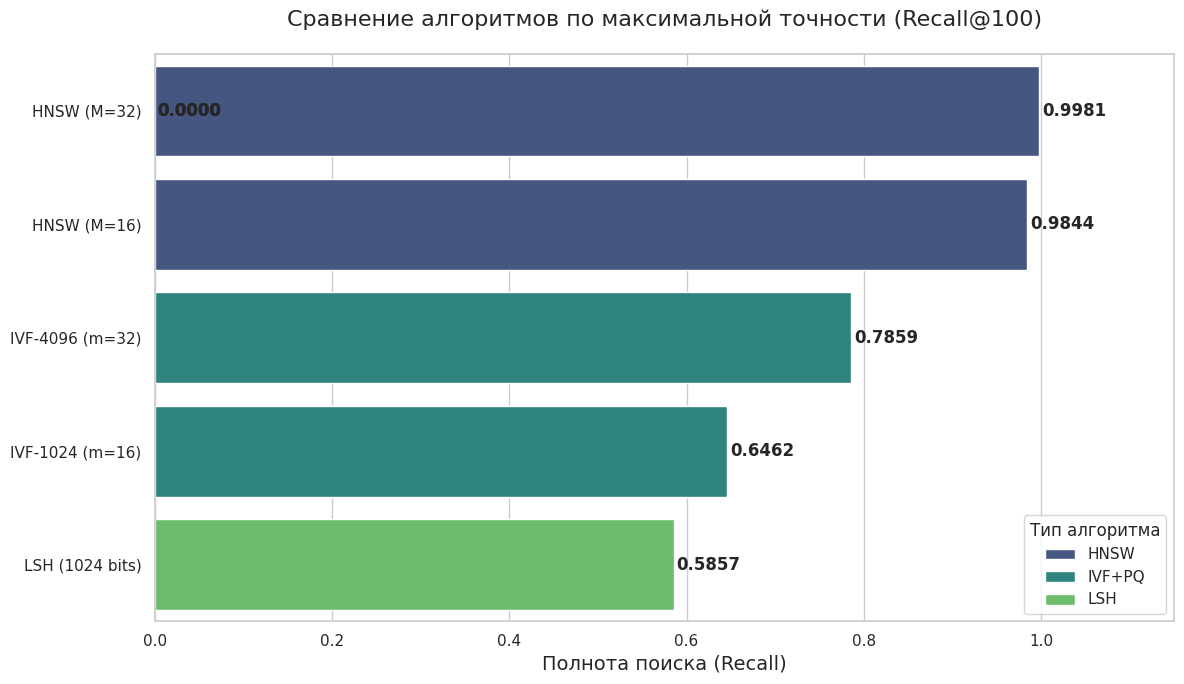

In [46]:
import seaborn as sns

comparison_data = [
    {'Method': 'LSH (1024 bits)', 'Recall': df_lsh['recall'].max(), 'Type': 'LSH'},

    {'Method': 'HNSW (M=16)', 'Recall': df_hnsw[df_hnsw['M']==16]['recall'].max(), 'Type': 'HNSW'},
    {'Method': 'HNSW (M=32)', 'Recall': df_hnsw[df_hnsw['M']==32]['recall'].max(), 'Type': 'HNSW'},

    {'Method': 'IVF-1024 (m=16)', 'Recall': df_ivf[(df_ivf['nlist']==1024) & (df_ivf['m']==16)]['recall'].max(), 'Type': 'IVF+PQ'},
    {'Method': 'IVF-4096 (m=32)', 'Recall': df_ivf[(df_ivf['nlist']==4096) & (df_ivf['m']==32)]['recall'].max(), 'Type': 'IVF+PQ'}
]

df_compare = pd.DataFrame(comparison_data).sort_values('Recall', ascending=False)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

plot = sns.barplot(x='Recall', y='Method', data=df_compare, hue='Type', palette='viridis', dodge=False)

for i in plot.patches:
    plot.annotate(format(i.get_width(), '.4f'),
                   (i.get_width(), i.get_y() + i.get_height() / 2.),
                   ha = 'center', va = 'center',
                   xytext = (25, 0),
                   textcoords = 'offset points',
                   fontsize=12, fontweight='bold')

plt.xlim(0, 1.15)
plt.title('Сравнение алгоритмов по максимальной точности (Recall@100)', fontsize=16, pad=20)
plt.xlabel('Полнота поиска (Recall)', fontsize=14)
plt.ylabel('', fontsize=14)
plt.legend(title='Тип алгоритма', loc='lower right')

plt.tight_layout()
plt.show()